In [41]:
import torch
from PIL import Image
import torchvision.transforms as T
import os
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

## 自定义数据集类

In [27]:
class NoiseImageDataset(Dataset):
    # 初始化
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_names = os.listdir(image_dir)

    # 获取数据集大小
    def __len__(self):
        return len(self.image_names)

    # 获取数据集的某一个数据
    def __getitem__(self, index):
        # 1. 图片的完整访问路径
        image_path = os.path.join(self.image_dir, self.image_names[index])
        # 2. 打开图片
        image = Image.open(image_path).convert("RGB")
        # 3. 应用转换操作,得到tensor
        if self.transform is not None:
            image_tensor = self.transform(image)
        else:
            raise ValueError("transform 参数不能为None!")
        # 4. 加入噪声,得到模型真正输入
        noise_factor = 0.5
        img_noise_tensor = image_tensor + noise_factor * torch.randn_like(image_tensor)
        # 将图片数据范围限制0-1
        img_noise_tensor = torch.clamp(img_noise_tensor, 0., 1.)

        return img_noise_tensor, image_tensor




In [28]:
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
])
dataset = NoiseImageDataset(image_dir="../common/dataset", transform=transform)
print(dataset[0])


(tensor([[[0.8304, 0.7443, 1.0000,  ..., 0.5156, 1.0000, 0.9162],
         [1.0000, 0.0000, 0.6003,  ..., 1.0000, 0.7223, 1.0000],
         [1.0000, 0.8809, 1.0000,  ..., 0.6833, 0.3223, 0.5339],
         ...,
         [1.0000, 1.0000, 0.3183,  ..., 1.0000, 1.0000, 0.7103],
         [1.0000, 0.0000, 1.0000,  ..., 1.0000, 0.4087, 0.8026],
         [1.0000, 0.6057, 1.0000,  ..., 0.3360, 0.9135, 0.7670]],

        [[0.7206, 0.6561, 0.2132,  ..., 1.0000, 0.9562, 1.0000],
         [0.1388, 0.4772, 0.8797,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 0.0000, 0.3828,  ..., 1.0000, 0.7966, 1.0000],
         ...,
         [0.9561, 0.7309, 0.8569,  ..., 0.4462, 0.2405, 1.0000],
         [1.0000, 1.0000, 0.6129,  ..., 1.0000, 0.9203, 0.3320],
         [0.7406, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],

        [[0.7269, 1.0000, 0.0419,  ..., 0.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 0.7326,  ..., 0.3217, 1.0000, 0.6317],
         [0.7310, 1.0000, 0.7747,  ..., 1.0000, 1.0000, 0

In [29]:
print(dataset[0][0].shape)

torch.Size([3, 64, 64])


## 划分数据集,构建加载器

In [30]:
# 划分数据集, 训练和测试集
train_dataset, val_dataset = random_split(dataset, [0.75, 0.25])
print(len(train_dataset))
print(len(val_dataset))

18640
6213


In [31]:
batch_size = 32

# 构建加载器
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(val_dataset, batch_size=batch_size)

In [32]:
for noise_img, image in train_loader:
    print(f"noise_img.shape: {noise_img.shape}, image.shape: {image.shape}")
    break

noise_img.shape: torch.Size([32, 3, 64, 64]), image.shape: torch.Size([32, 3, 64, 64])


## 定义模型

In [33]:
from torch import nn, optim


# 自定义神经网络类, 基于CNN的去噪器
class ConvDenoiser(nn.Module):
    def __init__(self):
        super(ConvDenoiser, self).__init__()
        # 编码器
        # 卷积层
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        # 通用池化层
        self.pool = nn.MaxPool2d(2, 2)
        # 解码器 - 转置卷积层
        self.conv_t1 = nn.ConvTranspose2d(8, 8, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.conv_t2 = nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.conv_t3 = nn.ConvTranspose2d(16, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        # 输出普通卷积层
        self.conv_out = nn.Conv2d(32, 3, kernel_size=3, padding=1)
    # 前向传播
    def forward(self,x):
        # 编码
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.relu(self.conv3(x))
        x = self.pool(x)
        # 解码
        x = torch.relu(self.conv_t1(x))
        x = torch.relu(self.conv_t2(x))
        x = torch.relu(self.conv_t3(x))
        y = torch.sigmoid(self.conv_out(x))

        return y




In [34]:
model = ConvDenoiser()

# 前向传播测试
input = torch.randn(1, 3, 64, 64)
output = model(input)
print(output.shape)

torch.Size([1, 3, 64, 64])


## 模型训练

In [35]:
# 超参数设置
lr = 1e-3
epochs = 10

# 定义设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [36]:
# 损失函数
loss_fn = nn.MSELoss()
# 优化器
optimizer = optim.Adam(model.parameters(), lr=lr)

In [37]:
# 训练
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    total = 0
    for noise_img, image in train_loader:
        input = noise_img.to(device)
        target = image.to(device)
        # 前向传播
        output = model(input)
        # 计算损失
        loss = loss_fn(output, target)
        # 反向传播 + 梯度清零 + 参数更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # 累加损失
        total_loss += loss.item()
        total += 1
    # 本轮训练结束,计算平均损失
    this_loss = total_loss / total
    print(f"epoch: {epoch+1}, loss: {this_loss}")



epoch: 1, loss: 0.03276581328227809
epoch: 2, loss: 0.012862156244487697
epoch: 3, loss: 0.011439502317637615
epoch: 4, loss: 0.01076474812288234
epoch: 5, loss: 0.01018843525153332
epoch: 6, loss: 0.008963053018699601
epoch: 7, loss: 0.008494010823218734
epoch: 8, loss: 0.008273088954920365
epoch: 9, loss: 0.008067998607863778
epoch: 10, loss: 0.007888605160465868


## 测试

In [38]:
# 取一个批次数据
data_iter  = iter(test_loader)
noise_img, image = next(data_iter)
noise_img = noise_img.to(device)


In [39]:
# 推理预测
with torch.no_grad():
    # 前向传播
    output = model(noise_img)
    print(f"output.shape: {output.shape}")



output.shape: torch.Size([32, 3, 64, 64])


In [40]:
# 3. 转成ndarray,方便画图
images_numpy = image.permute(0, 2, 3, 1).cpu().numpy()
noise_img_numpy = noise_img.permute(0, 2, 3, 1).cpu().numpy()
output_numpy = output.permute(0, 2, 3, 1).cpu().numpy()
print(f"output_numpy.shape: {output_numpy.shape}")

output_numpy.shape: (32, 64, 64, 3)


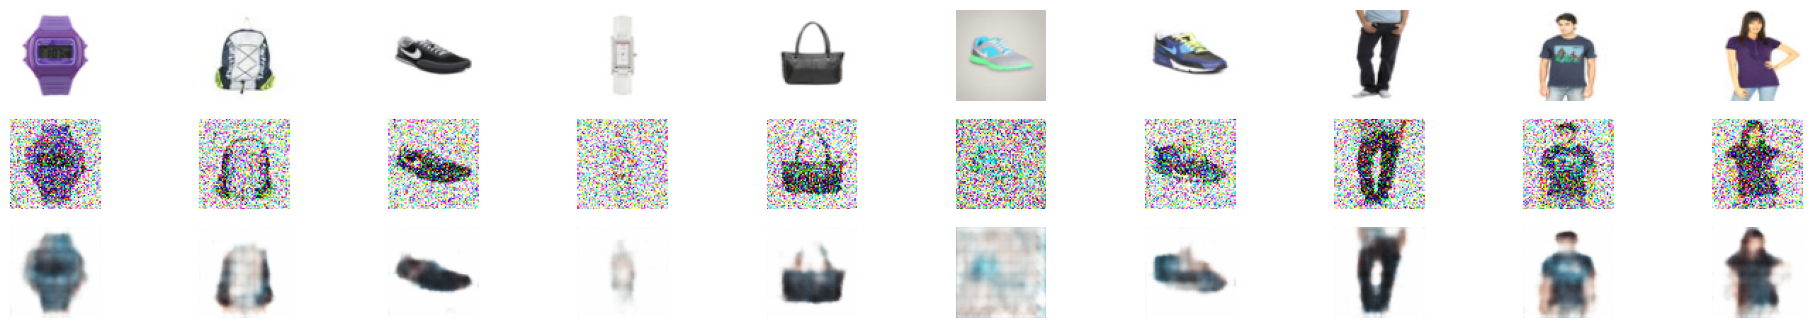

In [42]:
# 画图
fig, axes = plt.subplots(3, 10, figsize=(24, 4), sharey=True, sharex=True)

for ax_row, images in zip(axes,[images_numpy, noise_img_numpy, output_numpy]):
    for ax, img in zip(ax_row, images):
        ax.imshow(img)
        ax.set_axis_off()

plt.show()



## 文件名称排序

In [43]:
img_name1 = "image100.jpg"
img_name2 = "image25.jpg"
print(img_name1 < img_name2)

True


In [44]:
import re

img1 = re.split(r'([0-9]+)',img_name1)

img2 = re.split(r'([0-9]+)',img_name2)
print(img1)
print(img2)

['image', '100', '.jpg']
['image', '25', '.jpg']


In [45]:
# 定义函数对字符串和数字处理
convert = lambda str: int(str) if str.isdigit() else str.lower()

img1 = [convert(c) for c in img1]
img2 = [convert(c) for c in img2]

print(img1 < img2)


False


In [46]:
# 将数据集文件名排序
image_names = sorted(dataset.image_names, key=lambda x: [convert(c) for c in re.split(r'([0-9]+)',x)])
print(image_names)

['0.jpg', '1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg', '6.jpg', '7.jpg', '8.jpg', '9.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg', '27.jpg', '28.jpg', '29.jpg', '30.jpg', '31.jpg', '32.jpg', '33.jpg', '34.jpg', '35.jpg', '36.jpg', '37.jpg', '38.jpg', '39.jpg', '40.jpg', '41.jpg', '42.jpg', '43.jpg', '44.jpg', '45.jpg', '46.jpg', '47.jpg', '48.jpg', '49.jpg', '50.jpg', '51.jpg', '52.jpg', '53.jpg', '54.jpg', '55.jpg', '56.jpg', '57.jpg', '58.jpg', '59.jpg', '60.jpg', '61.jpg', '62.jpg', '63.jpg', '64.jpg', '65.jpg', '66.jpg', '67.jpg', '68.jpg', '69.jpg', '70.jpg', '71.jpg', '72.jpg', '73.jpg', '74.jpg', '75.jpg', '76.jpg', '77.jpg', '78.jpg', '79.jpg', '80.jpg', '81.jpg', '82.jpg', '83.jpg', '84.jpg', '85.jpg', '86.jpg', '87.jpg', '88.jpg', '89.jpg', '90.jpg', '91.jpg', '92.jpg', '93.jpg', '94.jpg', '95.jpg', '96.jpg', '97.jpg', '98.jpg', '99.jpg', '100.jpg'